In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flopy

In [2]:
nlay = 1
nrow = 1
ncol = 30
# Arreglo para la condición inicial
c1_ini = np.full((nlay,nrow,ncol), 1.0000329) # En todo el dominio
c1_ini[0, 0, 11] = 200.0  # Pulso en x_L

# Arreglo para la condición inicial
c2_ini = np.full((nlay,nrow,ncol), 3.294e-5) # En todo el dominio
c2_ini[0, 0, 11] = 1.647e-7  # Pulso en x_L

print(c1_ini)
print(c2_ini)

[[[  1.0000329   1.0000329   1.0000329   1.0000329   1.0000329
     1.0000329   1.0000329   1.0000329   1.0000329   1.0000329
     1.0000329 200.          1.0000329   1.0000329   1.0000329
     1.0000329   1.0000329   1.0000329   1.0000329   1.0000329
     1.0000329   1.0000329   1.0000329   1.0000329   1.0000329
     1.0000329   1.0000329   1.0000329   1.0000329   1.0000329]]]
[[[3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 1.647e-07 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05]]]


In [3]:
# Cargamos los modelos de transporte
o_sim1 = flopy.mf6.MFSimulation.load(sim_ws="io_mf6/c1/gwt", verbosity_level=0)
o_sim2 = flopy.mf6.MFSimulation.load(sim_ws="io_mf6/c2/gwt", verbosity_level=0)

# Obtenemos los objetos de los modelos
o_gwt1 = o_sim1.get_model("transport")
o_gwt2 = o_sim2.get_model("transport")

# Recuperamos las coordenadas del dominio
grid = o_gwt1.modelgrid
x = grid.xcellcenters[0] # centros de los volúmenes

# Recuperamos la concentración c1
c1_obj = o_gwt1.output.concentration()
c1 = c1_obj.get_data()[0,0]
times1 = np.asarray(c1_obj.get_times())

c1 = np.empty((len(times1)+1, len(x)), dtype=float)
c1[0] = c1_ini[0,0]
for i, t in enumerate(times1):
    c1[i+1] = c1_obj.get_data(totim = t)[0,0]

# Recuperamos la concentración c2
c2_obj = o_gwt2.output.concentration()
c2 = c2_obj.get_data()[0,0]
times2 = np.asarray(c2_obj.get_times())

c2 = np.empty((len(times2)+1, len(x)), dtype=float)
c2[0] = c2_ini[0,0]
for i, t in enumerate(times2):
    c2[i+1] = c2_obj.get_data(totim = t)[0,0]


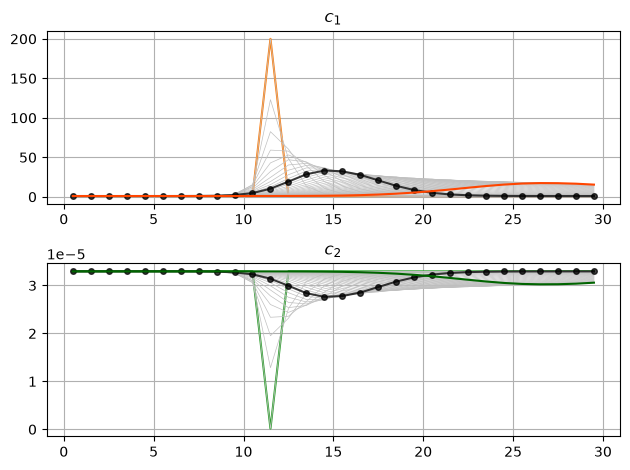

In [4]:
fig, ax = plt.subplots(2, 1)

ax[0].plot(x, c1[0], lw=1.5, ls = "-", color='C1')
ax[1].plot(x, c2[0], lw=1.5, ls = "-", color='C2')

for nt, t in enumerate(times1):
    ax[0].plot(x, c1[nt], lw=.5, color='silver')
    ax[1].plot(x, c2[nt], lw=.5, color='silver')

ax[0].plot(x, c1[10], lw=1.5, ls = "-", color='black',
          marker = "o", markersize="4", alpha = 0.75)
ax[1].plot(x, c2[10], lw=1.5, ls = "-", color='black',
          marker = "o", markersize="4", alpha = 0.75)

ax[0].plot(x, c1[-1], lw=1.5, ls = "-", color='orangered')
ax[1].plot(x, c2[-1], lw=1.5, ls = "-", color='darkgreen')

ax[0].set_title(f"$c_1$")
ax[1].set_title(f"$c_2$")

ax[0].grid()
ax[1].grid()


plt.tight_layout()
plt.show()